# **Altair / Vega-lite**

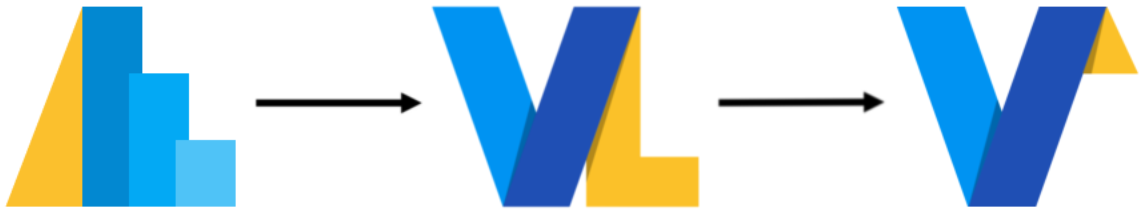

**Vega** to niskopoziomowa gramatyka wizualizacji i deklaratywny język (JSON) służący do projektowania interaktywnych grafik. Pozwala na precyzyjne opisanie wyglądu oraz zachowania wizualizacji, generując gotowe widoki w formacie Canvas lub SVG. Daje pełną kontrolę nad każdym detalem, ale wymaga bardzo szczegółowej konfiguracji.

**Vega-Lite** to wysokopoziomowa gramatyka interaktywnej grafiki zbudowana nad Vegą. Oferuje zwięzłą składnię JSON, która mapuje dane bezpośrednio na właściwości obiektów (punkty, słupki). Kompilator Vega-Lite automatycznie generuje osie, legendy i skale na podstawie domyślnych reguł.

**Altair (Vega-Altair)** to deklaratywna biblioteka wizualizacji dla Pythona, stanowiąca interfejs dla Vega-Lite. Dzięki prostemu i spójnemu API pozwala budować wykresy bezpośrednio na obiektach DataFrame, minimalizując czas pisania kodu na rzecz eksploracji danych. Altair tłumaczy kod Pythona na JSON Vega-Lite, który może być renderowany lokalnie lub w przeglądarce.


# **Dlaczego ktokolwiek chciałby tego używać?**

In [ ]:
from vega_datasets import data

cars_df = data.cars()
cars_df.head()

## **Deklaratywne API**

#### Imperatywny matplotlib

In [ ]:
import matplotlib.pyplot as plt

origins = sorted(cars_df['Origin'].unique())
fig, axs = plt.subplots(1, len(origins), figsize=(15, 5), sharex=True, sharey=True)

for ax, origin in zip(axs, origins):
    subset = cars_df[cars_df['Origin'] == origin]
    ax.scatter(subset['Horsepower'], subset['Miles_per_Gallon'])
    
    ax.set_xlabel('Horsepower')
    ax.set_title(origin)

axs[0].set_ylabel('Miles_per_Gallon')
plt.tight_layout()
plt.show()

#### Deklaratywny altair

In [ ]:
import altair as alt

alt.Chart(cars_df).mark_point().encode(
    alt.X('Horsepower'),
    alt.Y('Miles_per_Gallon'),
    alt.Column('Origin')
)

## **Intuicyjność**

#### Kolor

In [ ]:
alt.Chart(cars_df).mark_point().encode(
    alt.X('Horsepower'),
    alt.Y('Miles_per_Gallon'),
    alt.Color('Origin')
)

#### Rozmiar

In [ ]:
alt.Chart(cars_df).mark_point().encode(
    alt.X('Horsepower'),
    alt.Y('Miles_per_Gallon'),
    alt.Size('Displacement')
)

#### Kolor i rozmiar

In [ ]:
alt.Chart(cars_df).mark_point().encode(
    alt.X('Horsepower'),
    alt.Y('Miles_per_Gallon'),
    alt.Color('Origin'),
    alt.Size('Displacement')
)

## **Transformacje danych**

#### Matplotlib + Pandas

In [ ]:
import pandas as pd

usa_df = cars_df[cars_df['Origin'] == 'USA']
cylinders_means = usa_df.groupby('Cylinders')['Miles_per_Gallon'].mean().reset_index()

fig, ax = plt.subplots()
ax.bar(cylinders_means['Cylinders'].astype(str), cylinders_means['Miles_per_Gallon'])
ax.set_xlabel('Cylinders')
ax.set_ylabel('Mean of Miles_per_Gallon')
ax.set_title('USA Cars')

plt.show()

#### Altair

In [ ]:
alt.Chart(
    cars_df
).transform_filter(
    alt.datum.Origin == 'USA'
).mark_bar().encode(
    alt.X('Cylinders:O'),
    alt.Y('mean(Miles_per_Gallon):Q')
).properties(
    title='USA Cars',
    width=300
)

## **Interaktywność**

In [ ]:
origin_sel = alt.selection_point(fields=["Origin"], bind="legend")

alt.Chart(cars_df).mark_circle().encode(
    alt.X("Horsepower"),
    alt.Y("Miles_per_Gallon"),
    alt.Color("Origin"),
    alt.Size("Displacement"),
    opacity=alt.condition(origin_sel, alt.value(0.7), alt.value(0.1)),
    tooltip=["Name", "Origin", "Horsepower", "Miles_per_Gallon", "Displacement"],
).add_params(
    origin_sel
).properties(
    width=800,
    height=600
).interactive()

## **Popularność**

In [ ]:
popularity_df = pd.DataFrame({
    'library': ['matplotlib', 'seaborn', 'plotly', 'altair', 'bokeh', 'plotnine'],
    'downloads': [200_140_390, 45_680_859, 57_206_796, 49_582_812, 7_734_742, 3_352_389]
})

alt.Chart(popularity_df).mark_bar().encode(
    alt.X('downloads'),
    alt.Y('library').sort('-x'),
    tooltip=['library', 'downloads'],
    color=alt.condition(
        alt.datum.library == 'altair',
        alt.value('orange'),
        alt.value('steelblue')
    )
).properties(
    title='Downloads of Python Visualization Libraries (18.04.2026 - pypistats.org)',
    width=600,
    height=300
).configure_axis(
    labelFontSize=14,
    titleFontSize=14
).configure_title(
    fontSize=16,
)

## **Problem - Limit 5000 wierszy**

In [ ]:
flights_df = data.flights_3m()

print(f"Number of rows in flights_df: {len(flights_df)}")
flights_df.head()

#### Domyślny transformator

In [ ]:
alt.data_transformers.enable("default") # domyślny transformator danych

alt.Chart(flights_df).mark_bar().encode(
    alt.X('origin').sort('-y'),
    alt.Y('mean(delay)')
)

In [ ]:
chart = alt.Chart(flights_df[:5000]).mark_bar().encode(
    alt.X('origin').sort('-y'),
    alt.Y('mean(delay)')
)

print(chart.to_json())

#### Transformator do JSON

In [ ]:
alt.data_transformers.enable("json")

chart = alt.Chart(flights_df).mark_bar().encode(
    alt.X('origin').sort('-y'),
    alt.Y('mean(delay)')
)

chart.show()

In [ ]:
print(chart.to_json())

#### Transformator **VegaFusion**

In [ ]:
alt.data_transformers.enable("vegafusion")

chart = alt.Chart(flights_df).mark_bar().encode(
    alt.X('origin').sort('-y'),
    alt.Y('mean(delay)')
)

chart.show()

In [ ]:
print(chart.to_json(format='vega'))

# **Podstawy**

### Wczytanie danych

In [ ]:
movies_df = data.movies()
movies_df['Release_Date'] = pd.to_datetime(movies_df['Release_Date'])
movies_df['Release_Year'] = movies_df['Release_Date'].dt.year
movies_df['Profit'] = movies_df['Worldwide_Gross'] - movies_df['Production_Budget']
movies_df = movies_df[['Title', 'Major_Genre', 'Production_Budget', 'Worldwide_Gross', 'IMDB_Rating', 'Release_Year', 'Profit']]
movies_df = movies_df.dropna()
movies_df.head()

### Typy danych w Altair

- `Q` - quantitive - wartości numeryczne
- `N` - nominal - wartości nieuporządkowana
- `O` - ordinal - wartości uporządkowane,
- `T` - temporal - data/czas

In [ ]:
movies_df.dtypes

### Tworzenie wykresu

In [ ]:
movie_scatter = (
    alt.Chart(movies_df)
    .mark_point(size=70, opacity=0.5)
    # .mark_circle(size=70, opacity=0.5)
    # .mark_square(size=70, opacity=0.5)
    .encode(
        x='Production_Budget:Q',
        y='IMDB_Rating:Q',
        color='Major_Genre:N',
        # shape='Major_Genre:N',
        # size='Profit:Q',
        tooltip=['Title:N', 'Major_Genre:N', 'Production_Budget:Q', 'IMDB_Rating:Q']
    )
    # .encode(
    #     alt.X('Production_Budget', type='quantitative'),
    #     alt.Y('IMDB_Rating', type='quantitative'),
    #     alt.Color('Major_Genre', type='nominal'),
    #     # alt.Shape('Major_Genre', type='nominal'),
    #     # alt.Size('Profit', type='quantitative'),
    #     tooltip=['Title:N', 'Major_Genre:N', 'Production_Budget:Q', 'IMDB_Rating:Q']
    # )
    .properties(width=600, height=400)
)

movie_scatter.show()

### Agregacje

In [ ]:
genre_counts = (
    alt.Chart(movies_df)
    .mark_bar()
    .encode(
        y=alt.Y('Major_Genre:N', sort='-x'),
        x='count()',
        # x='mean(IMDB_Rating):Q',
        # x='max(IMDB_Rating):Q',
        color=alt.Color('Major_Genre:N', legend=None),
        tooltip=[
            'Major_Genre:N',
            'count()',
            # 'min(IMDB_Rating):Q',
        ]
        )
).properties(width=600, height=400)

genre_counts.show()

In [ ]:
genre_counts.transformed_data() # wymaga VegaFusion

### Filtrowanie

In [ ]:
profit_chart = alt.Chart(movies_df).mark_circle(size=100).encode(
    x=alt.X('Production_Budget:Q'),
    y=alt.Y('Profit:Q'),
    color=alt.Color('Major_Genre:N'),
    tooltip=['Title:N', 'Release_Year:O', 'Profit:Q']
).transform_filter(
    alt.datum.Release_Year == 1998
).properties(
    width=600,
    height=400,
)

profit_chart.show()

### Łączenie wykresów

In [ ]:
movie_combined = movie_scatter | genre_counts
# movie_combined = movie_scatter & genre_counts
movie_combined.show()

### Interaktywność

In [ ]:
selection = alt.selection_point(fields=['Major_Genre'])
interval = alt.selection_interval()

movie_scatter = (
    alt.Chart(movies_df)
    .mark_point(size=70)
    .encode(
        x='Production_Budget:Q',
        y='IMDB_Rating:Q',
        color=alt.condition(selection, 'Major_Genre:N', alt.value('lightgray')),
        opacity=alt.condition(selection & interval, alt.value(0.7), alt.value(0.1)),
        tooltip=['Title:N', 'Major_Genre:N', 'Production_Budget:Q', 'IMDB_Rating:Q']
    )
    .properties(width=600, height=400)
    .add_params(interval)
)

genre_counts = (
    alt.Chart(movies_df)
    .mark_bar()
    .encode(
        y=alt.Y('Major_Genre:N', sort='-x'),
        x='count()',
        color=alt.condition(selection, alt.Color('Major_Genre:N', legend=None), alt.value('lightgray')),
        tooltip=['Major_Genre:N', 'count()']
    )
    .properties(width=600, height=400)
    .add_params(selection)
    .transform_filter(interval)
)


movie_combined = movie_scatter | genre_counts
movie_combined.show()

In [ ]:
year_slider = alt.binding_range(
    min=int(movies_df['Release_Year'].min()), 
    max=2010, 
    step=1, 
    name='Selected Year: '
)

year_selection = alt.selection_point(
    fields=['Release_Year'], 
    bind=year_slider, 
    value=[{'Release_Year': 1998}],
    name='Year'
)

profit_chart = alt.Chart(movies_df).mark_circle(size=100).encode(
    x=alt.X('Production_Budget:Q'),
    y=alt.Y('Profit:Q'),
    color=alt.Color('Major_Genre:N'),
    tooltip=['Title:N', 'Release_Year:O', 'Profit:Q']
).add_params(
    year_selection
).transform_filter(
    year_selection
).properties(
    width=600,
    height=400,
)

profit_chart.show()

In [ ]:
simple_dashboard = movie_combined & profit_chart
simple_dashboard.save('simple_dashboard.html')